In [ ]:
%pip install puremacro


# Applied Fiscal Multipliers and Debt Sustainability Analysis

**How do tax-response estimates change across identification assumptions, and how does a calibrated primary-balance adjustment affect debt risk?**

The fiscal block uses frozen US quarterly aggregates and observed narrative tax series from the bundled `tax14` data. It compares a Blanchard-Perotti-style SVAR, Romer-Romer narrative LPs, and LP-IV using the observed Mertens-Ravn unanticipated series. These simplified specifications are teaching examples, not exact replications of all three papers.

A separate, fixed-seed debt simulation uses calibrated growth, interest-rate and primary-balance dynamics. It does not incorporate the estimated multipliers or their uncertainty. Connecting the two blocks requires an explicit policy-to-growth channel, explored in the final exercise.

## The method in math

The fiscal VAR contains $X_t=(\tau_t,g_t,y_t)'$, with each series expressed as 100 times its real log. The institutional tax elasticity is $\theta=2.08$, giving the adjusted tax residual $e_t^\tau=u_t^\tau-\theta u_t^y$. The SVAR identifies a tax shock using that restriction and predetermined spending.

Narrative LPs regress $y_{t+h}-y_{t-1}$ on observed exogenous tax changes, measured in percent of GDP, with four lags plus one augmentation lag of GDP and the tax series at every horizon and Eicker-Huber-White standard errors (lag-augmented LP, Montiel Olea and Plagborg-Møller 2021). LP-IV instead instruments the raw VAR tax residual with the observed unanticipated narrative measure:
$$\widehat m_{IV}(h)=\frac{1}{\overline{T/Y}}\frac{\widehat{\operatorname{Cov}}(y_{t+h}-y_{t-1},z_t\mid W_t)}{\widehat{\operatorname{Cov}}(u_t^\tau,z_t\mid W_t)}.$$
A large first stage does not establish exclusion. We report horizon-specific HAC effective $F$ statistics, their MOP critical values, and Anderson-Rubin confidence-set types rather than enforce an $F>10$ threshold. Different controls and estimation samples also affect comparisons.

Panel (b) reports average GDP level responses $\bar m(H)=(H+1)^{-1}\sum_{h=0}^H m(h)$. A cumulative fiscal multiplier instead requires the ratio of cumulative output changes to cumulative fiscal changes in compatible units; the average here is not that ratio.

The calibrated DSA uses annual growth/rate percentages and an annual primary balance in percentage points of GDP:
$$d_t\approx d_{t-1}\left[1+\frac{r_t-g_t}{400}\right]-\frac{pb_t}{400}.$$
Thus `pb_shift=1.0` improves the annual primary balance by one percentage point of GDP. Debt `d0=0.65` is a ratio. The 80% debt threshold is illustrative, not a universal prudential limit.

**Intuition.** Fiscal revenues and output move together even without discretionary tax changes, so identifying a causal response requires assumptions beyond regression fit. The narrative instrument must originate in the historical record; constructing it from the tax residual would mechanically create relevance without supplying exogeneity. A weak first stage can make LP-IV point estimates unstable.

The debt simulation isolates a different mechanism: holding the growth and rate paths fixed, a higher primary balance reduces debt. Its risk probabilities describe this calibration and omit fiscal feedback onto growth, default, and parameter uncertainty.

Sample: 1950-01-01 to 2006-10-01 (T = 228 quarters)
Mean Federal Tax / GDP = 0.121  ->  1% of GDP tax shock requires 8.3% revenue rise
LP-IV Impact Effective F: 1.35; 10% bias critical value: 23.11
 h    mop_f  mop_cv_10    ar_set_type
 0 1.347081  23.108511 unbounded_rays
 1 1.346742  23.108511 unbounded_rays
 2 1.346842  23.108511 unbounded_rays
 3 1.346516  23.108511 unbounded_rays
 4 1.343690  23.108511 unbounded_rays
 5 1.339568  23.108511 unbounded_rays
 6 1.343092  23.108511 unbounded_rays
 7 1.351540  23.108511 unbounded_rays
 8 1.362051  23.108511 unbounded_rays
 9 1.366228  23.108511 unbounded_rays
10 1.368756  23.108511 unbounded_rays
11 1.367864  23.108511 unbounded_rays
12 1.370904  23.108511       all_real
13 1.383651  23.108511       all_real
14 0.004403  23.108511       all_real
15 0.004361  23.108511       all_real
16 0.004271  23.108511       all_real
Impact Multipliers (h=0): BP = -0.18 | MR = -2.61 | RR = -0.22
2-Year Multipliers (h=8): BP = -1.21 | MR = -5.98 | RR 

DSA Simulation Dimensions: (1000, 21)
Baseline Breach Probability (>80% GDP): 19.6%
Probability of Non-Stabilization: 72.3%
Terminal median debt (quarter 20): baseline 71.1% | deficit stress (pb_shift = -1) 76.1%


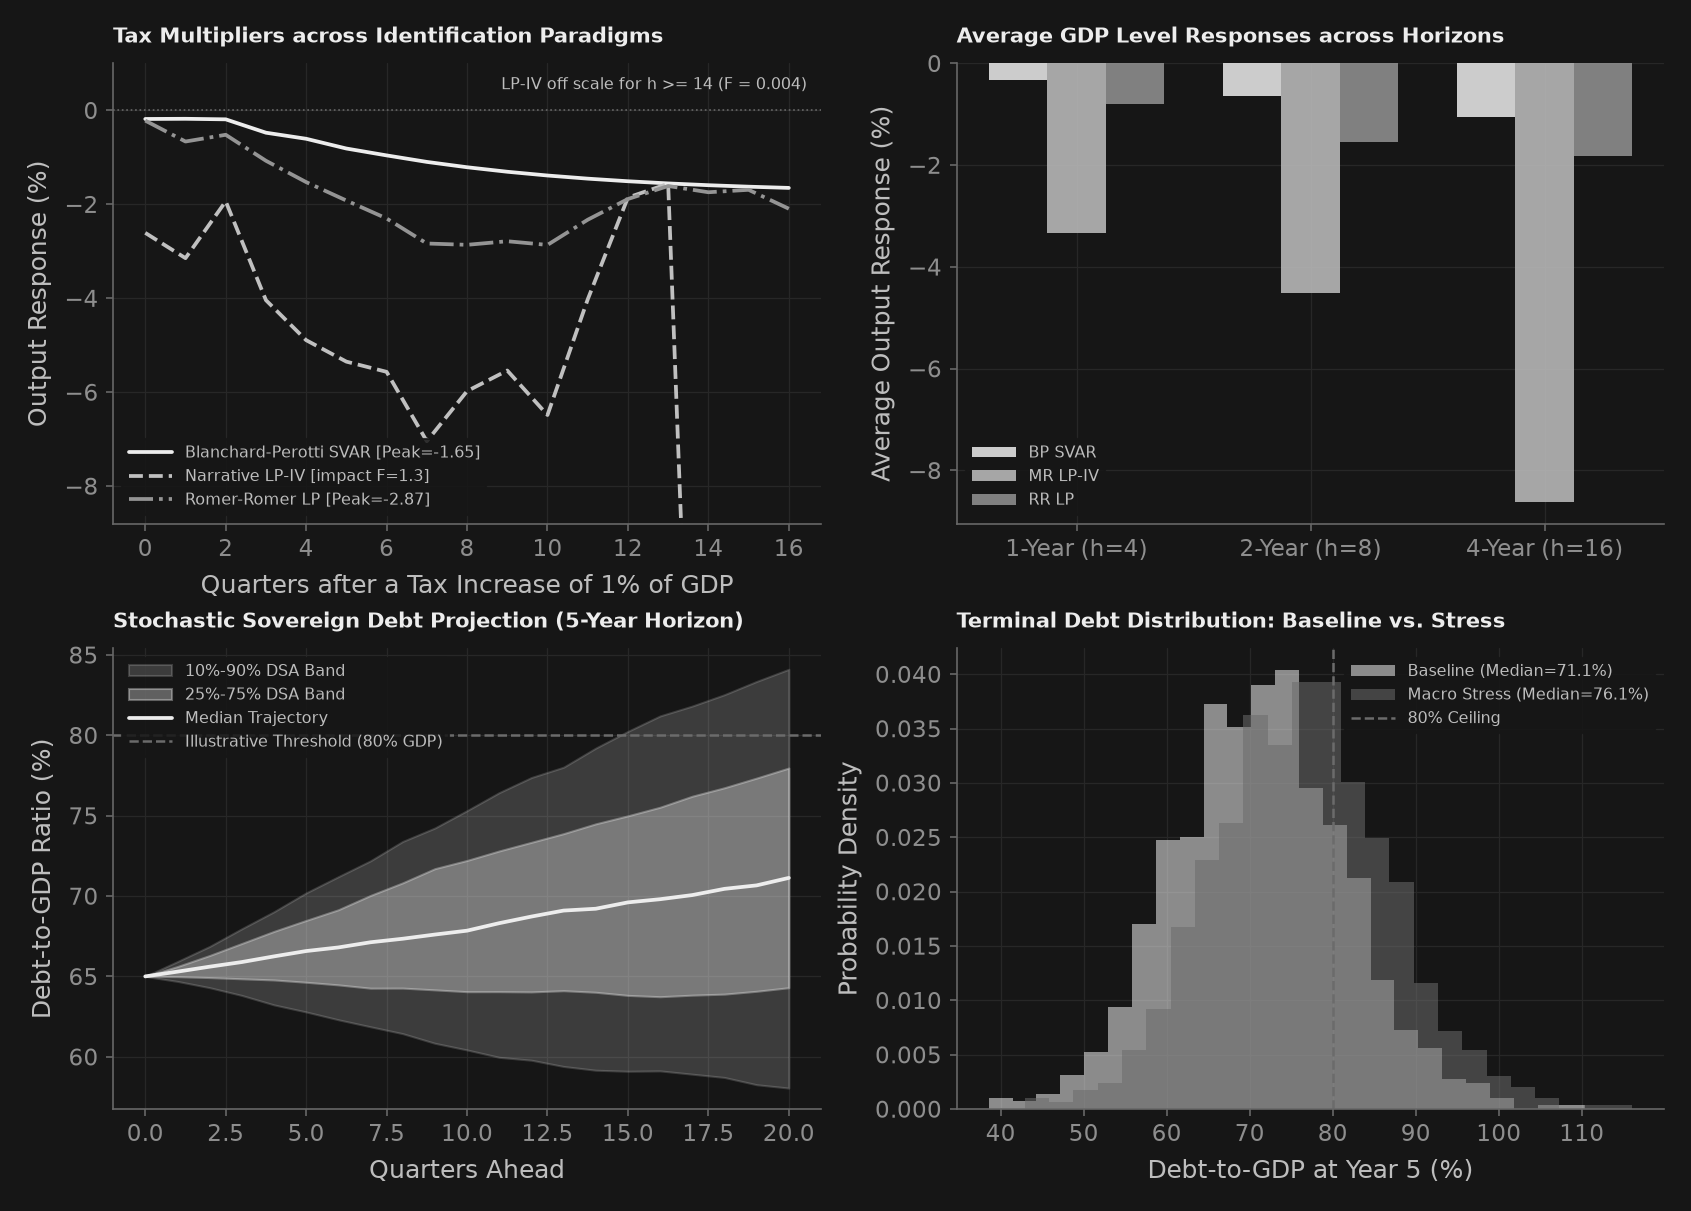

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.datasets import load_narrative_tax_shocks
from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.lp.la_lp import la_lp
from puremacro.lp.iv import lp_iv

# --- 1. Load Empirical Fiscal Panel and Narrative Tax Records ---------------
# Load frozen quarterly US fiscal aggregates (taxes, spending, GDP, deflator)
fiscal = load_csv("tax14_us_fiscal")
fiscal["date"] = pd.to_datetime(fiscal["date"])
fiscal = fiscal.set_index("date")

d = fiscal.loc["1950-01-01":"2006-12-31"].copy()
d["tau"] = 100 * np.log(d["fedtax"] / d["gdpdef"])    # Log real federal taxes
d["g"] = 100 * np.log(d["fedspend"] / d["gdpdef"])    # Log real federal spending
d["y"] = 100 * np.log(d["gdpc1"])                     # Log real GDP

tax_share = float((d["fedtax"] / d["gdp"]).mean())
SCALE = 1.0 / tax_share                                # Scaling factor: 1% of GDP tax shock

# Merge Valerie Ramey narrative tax shock records
tax_shocks = load_narrative_tax_shocks()
d["rr"] = tax_shocks["romer_romer_exog"].reindex(d.index.to_period("Q-DEC")).fillna(0.0).values
d["mtu"] = tax_shocks["unanticipated"].reindex(d.index.to_period("Q-DEC")).fillna(0.0).values

print(f"Sample: {d.index[0].date()} to {d.index[-1].date()} (T = {len(d)} quarters)")
print(f"Mean Federal Tax / GDP = {tax_share:.3f}  ->  1% of GDP tax shock requires {SCALE:.1f}% revenue rise")
assert len(d) == 228, "Sample should contain 228 quarters"
assert 0.10 < tax_share < 0.15, "Tax share should lie in historical [10%, 15%] range"

# --- 2. Estimate Multipliers: BP SVAR, RR LP, and MR LP-IV ------------------
H = 16
hgrid = np.arange(H + 1)

# (a) Blanchard-Perotti (2002) SVAR with institutional elasticity theta = 2.08
Y_var = d[["tau", "g", "y"]].to_numpy()
A_list, c_vec, Sigma, resid, _ = estimate_var(Y_var, p=4)

theta = 2.08
u_tau, u_g, u_y = resid[:, 0], resid[:, 1], resid[:, 2]
e_tau = u_tau - theta * u_y                           # Cyclically adjusted tax residual
e_g = u_g                                             # Government spending predetermined within quarter
Z_bp = np.column_stack([e_tau, e_g])
X_bp = np.column_stack([u_tau, u_g])
b_bp = np.linalg.solve(Z_bp.T @ X_bp, Z_bp.T @ u_y)   # Instrumental variables estimator for GDP equation
e_y = u_y - X_bp @ b_bp

A0 = np.array([
    [1.0, 0.0, -theta],
    [0.0, 1.0, 0.0],
    [-b_bp[0], -b_bp[1], 1.0]
])
B_bp = np.linalg.inv(A0) @ np.diag([e_tau.std(), e_g.std(), e_y.std()])
irfs_bp = var_irf(A_list, B_bp, horizon=H)
c_bp = SCALE / irfs_bp[0, 0, 0]
m_bp = irfs_bp[:, 2, 0] * c_bp

# (b) Romer-Romer (2010) narrative local projections, lag-augmented: n_lags=4 plus the
# default single extra lag (Montiel Olea-Plagborg-Moller 2021), EHW standard errors.
lp_rr = la_lp(d, y="y", x="rr", horizons=range(0, H + 1), n_lags=4, alpha=0.10)
m_rr = lp_rr["beta"].to_numpy()

# (c) LP-IV with the observed Mertens-Ravn unanticipated narrative series.
# Instrument the raw tax residual; unavailable presample residuals remain missing.
d["tax_innovation"] = np.nan
d.iloc[4:, d.columns.get_loc("tax_innovation")] = u_tau
d["z_narrative"] = d["mtu"]
res_iv = lp_iv(
    d, y="y", x="tax_innovation", z="z_narrative",
    horizons=range(0, H + 1), n_lags=2, anderson_rubin=True,
)
f_stat_iv = float(res_iv.iloc[0]["mop_f"])
m_iv = res_iv["beta"].to_numpy() * SCALE

print(f"LP-IV Impact Effective F: {f_stat_iv:.2f}; 10% bias critical value: {res_iv.iloc[0]['mop_cv_10']:.2f}")
print(res_iv[["h", "mop_f", "mop_cv_10", "ar_set_type"]].to_string(index=False))
print(f"Impact Multipliers (h=0): BP = {m_bp[0]:.2f} | MR = {m_iv[0]:.2f} | RR = {m_rr[0]:.2f}")
print(f"2-Year Multipliers (h=8): BP = {m_bp[8]:.2f} | MR = {m_iv[8]:.2f} | RR = {m_rr[8]:.2f}")

# Influence check: how much of the LP-IV first stage does one quarter carry?
big_q = d["z_narrative"].abs().idxmax()
d_drop = d.assign(z_narrative=d["z_narrative"].where(d.index != big_q, 0.0))
f_drop = float(lp_iv(d_drop, y="y", x="tax_innovation", z="z_narrative",
                     horizons=[0], n_lags=2).iloc[0]["mop_f"])
print(f"Largest unanticipated change: {big_q.year}Q{big_q.quarter} "
      f"({d.loc[big_q, 'z_narrative']:+.2f}% of GDP); impact effective F without it: {f_drop:.3f}")

# Headline assertions
assert -2.0 <= m_bp[0] <= 0.0, "Impact tax multiplier in BP SVAR must be negative and bounded"
assert np.isfinite(res_iv["mop_f"]).all() and (res_iv["mop_f"] >= 0).all()
np.testing.assert_array_equal(d["z_narrative"], d["mtu"])
assert d["tax_innovation"].iloc[:4].isna().all()
assert m_rr[8] < m_bp[8], "Romer-Romer 2-year multiplier must be more contractionary than BP"
assert f_drop < 0.1 * f_stat_iv, "the LP-IV first stage should rest on a single quarter"

# --- 3. Stochastic Sovereign Debt Sustainability Simulator (DSA) -------------
def simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42, pb_shift=0.0,
                            m=0.0, shocks=True):
    """Quarterly debt paths; pb_shift is in annual percentage points of GDP.

    Used by the final exercise only: m > 0 lowers annual growth by m * pb_shift points
    in quarters 1-4 (the GDP level ends m * pb_shift % lower, so m is a level
    multiplier), in the debt equation only; shocks=False zeroes the innovations
    (the draws are still taken, so the random stream stays aligned).
    """
    rng_sim = np.random.default_rng(seed)
    # Calibrated macro dynamics: real growth g=2.2%, real rate r=1.8%, primary deficit pb=-1.5%
    mu = np.array([2.2, 1.8, -1.5 + pb_shift])
    A = np.array([
        [0.60, -0.10,  0.05],
        [0.10,  0.80, -0.05],
        [0.20, -0.10,  0.70]
    ])
    cov = np.array([
        [ 2.5, -0.3,  0.4],
        [-0.3,  1.2, -0.2],
        [ 0.4, -0.2,  1.0]
    ])
    paths = np.zeros((n_sims, horizon_quarters + 1))
    paths[:, 0] = d0
    for s in range(n_sims):
        st = mu.copy()
        for t in range(1, horizon_quarters + 1):
            shk = rng_sim.multivariate_normal(np.zeros(3), cov) * (1.0 if shocks else 0.0)
            st = mu + A @ (st - mu) + shk
            g_t, r_t, pb_t = st
            if t <= 4:
                g_t = g_t - m * pb_shift             # one-year growth hit (0 by default)
            # Quarterly debt snowball: d_t = d_{t-1} * (1 + (r_t - g_t)/400) - pb_t/400
            d_prev = paths[s, t - 1]
            paths[s, t] = d_prev * (1.0 + (r_t - g_t) / 400.0) - (pb_t / 400.0)
    return paths

dsa_base = simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42)
dsa_stress = simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42, pb_shift=-1.0)

prob_breach = float(np.mean(np.max(dsa_base, axis=1) > 0.80))
prob_non_stab = float(np.mean(dsa_base[:, -1] > 0.65))
print(f"DSA Simulation Dimensions: {dsa_base.shape}")
print(f"Baseline Breach Probability (>80% GDP): {prob_breach:.1%}")
print(f"Probability of Non-Stabilization: {prob_non_stab:.1%}")
print(f"Terminal median debt (quarter 20): baseline {np.median(dsa_base[:, -1]):.1%} | "
      f"deficit stress (pb_shift = -1) {np.median(dsa_stress[:, -1]):.1%}")

assert dsa_base.shape == (1000, 21), f"Expected (1000, 21), got {dsa_base.shape}"
assert 0.0 <= prob_breach <= 1.0, "Breach probability must lie in [0, 1]"

# --- 4. Hero Figure: Multipliers & Sovereign DSA Dashboard -------------------
fig, axes = _nbstyle.figura(2, 2, figsize=(11.0, 7.8))
c = _nbstyle.palette(4)

# Panel 1: Multiplier Dynamics across Horizons
ax1 = axes[0, 0]
ax1.plot(hgrid, m_bp, color=c[0], lw=1.8, label=f"Blanchard-Perotti SVAR [Peak={m_bp.min():.2f}]")
ax1.plot(hgrid, m_iv, color=c[1], lw=1.8, ls="--", label=f"Narrative LP-IV [impact F={f_stat_iv:.1f}]")
ax1.plot(hgrid, m_rr, color=c[2], lw=1.8, ls="-.", label=f"Romer-Romer LP [Peak={m_rr.min():.2f}]")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
# From h=14 the 2003Q3 quarter leaves the LP-IV sample and the first stage collapses;
# bound the axis so the BP and RR paths stay readable.
lo1 = 1.25 * min(m_bp.min(), m_rr.min(), m_iv[:14].min())
ax1.set_ylim(lo1, 1.0)
ax1.text(0.98, 0.97, f"LP-IV off scale for h >= 14 (F = {res_iv['mop_f'].iloc[14]:.3f})",
         transform=ax1.transAxes, ha="right", va="top", fontsize=7.5, color=_nbstyle.TEXTO)
ax1.set_title("Tax Multipliers across Identification Paradigms", fontsize=10)
ax1.set_xlabel("Quarters after a Tax Increase of 1% of GDP")
ax1.set_ylabel("Output Response (%)")
ax1.legend(loc="lower left", fontsize=7.5, frameon=True)

# Panel 2: Average GDP Level Responses (not cumulative fiscal multipliers)
ax2 = axes[0, 1]
horiz_labels = ["1-Year (h=4)", "2-Year (h=8)", "4-Year (h=16)"]
idx_h = [4, 8, 16]
cum_bp = [np.mean(m_bp[:h+1]) for h in idx_h]
cum_iv = [np.mean(m_iv[:h+1]) for h in idx_h]
cum_rr = [np.mean(m_rr[:h+1]) for h in idx_h]

x_pos = np.arange(len(horiz_labels))
width = 0.25
ax2.bar(x_pos - width, cum_bp, width=width, color=c[0], alpha=0.85, label="BP SVAR")
ax2.bar(x_pos, cum_iv, width=width, color=c[1], alpha=0.85, label="MR LP-IV")
ax2.bar(x_pos + width, cum_rr, width=width, color=c[2], alpha=0.85, label="RR LP")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(horiz_labels)
ax2.set_title("Average GDP Level Responses across Horizons", fontsize=10)
ax2.set_ylabel("Average Output Response (%)")
ax2.legend(loc="lower left", fontsize=7.5, frameon=True)

# Panel 3: Stochastic Sovereign DSA Fan Chart
ax3 = axes[1, 0]
q10, q25, q50, q75, q90 = [np.percentile(dsa_base, p, axis=0) * 100 for p in [10, 25, 50, 75, 90]]
t_axis = np.arange(21)
ax3.fill_between(t_axis, q10, q90, color=c[0], alpha=0.18, label="10%-90% DSA Band")
ax3.fill_between(t_axis, q25, q75, color=c[0], alpha=0.35, label="25%-75% DSA Band")
ax3.plot(t_axis, q50, color=c[0], lw=1.8, label="Median Trajectory")
ax3.axhline(80.0, color=c[3], lw=1.2, ls="--", label="Illustrative Threshold (80% GDP)")
ax3.set_title("Stochastic Sovereign Debt Projection (5-Year Horizon)", fontsize=10)
ax3.set_xlabel("Quarters Ahead")
ax3.set_ylabel("Debt-to-GDP Ratio (%)")
ax3.legend(loc="upper left", fontsize=7.5, frameon=True)

# Panel 4: Debt Probability Density at Terminal Horizon (Quarter 20)
ax4 = axes[1, 1]
term_base = dsa_base[:, -1] * 100
term_stress = dsa_stress[:, -1] * 100
ax4.hist(term_base, bins=25, density=True, color=c[0], alpha=0.55, label=f"Baseline (Median={np.median(term_base):.1f}%)")
ax4.hist(term_stress, bins=25, density=True, color=c[3], alpha=0.55, label=f"Macro Stress (Median={np.median(term_stress):.1f}%)")
ax4.axvline(80.0, color=c[3], lw=1.2, ls="--", label="80% Ceiling")
ax4.set_title("Terminal Debt Distribution: Baseline vs. Stress", fontsize=10)
ax4.set_xlabel("Debt-to-GDP at Year 5 (%)")
ax4.set_ylabel("Probability Density")
ax4.legend(loc="upper right", fontsize=7.5, frameon=True)

**Read the output.** At the two-year horizon the three point estimates are −1.21 (BP SVAR), −2.86 (RR lag-augmented LP) and −5.98 (LP-IV), each per tax increase of 1% of GDP. The first panel compares conditional point estimates, not a verified ranking of causal multipliers. The observed narrative instrument is weak in this specification (impact effective $F = 1.35$, against the displayed 23.11 critical value), and the Anderson-Rubin set is unbounded at every horizon: two rays through $h=11$, the whole real line from $h=12$. The influence check shows why. The first stage rests on one quarter, 2003Q3 (−2.86% of GDP in the unanticipated series); set it to zero and the impact $F$ falls to 0.002. From $h=14$ that quarter leaves the estimation sample, because its outcome would fall after 2006Q4, which is why the $F$ column collapses there. Read the LP-IV path as uninformative, not as evidence of a large multiplier. The second panel averages GDP level responses, not cumulative fiscal multipliers.

The last two panels show the independent calibrated debt experiment. In the baseline, 19.6% of the 1,000 paths cross 80% of GDP at some point within five years and 72.3% end above the initial 65%; the terminal median is 71.1%, against 76.1% under the one-point deficit stress. Baseline and deficit-stress paths use the same random draws, making their difference attributable to the one-percentage-point primary-balance shift within this model. Read these probabilities as simulation outputs, not empirical estimates of a country's default risk.

## Your turn — when is fiscal consolidation self-defeating?

The calibrated DSA holds growth fixed, so a higher primary balance always lowers debt. Add the missing growth channel: `simulate_stochastic_dsa(..., m=...)` lowers annual growth by $m \times$ `pb_shift` points in quarters 1-4, so the GDP level ends $m \times$ `pb_shift` percent lower and $m$ is a level multiplier. The hit enters only the debt equation, not the VAR state, so there are no automatic stabilizers. The cell compares a 1 pp consolidation with no consolidation, from the same initial debt and with the same draws.

**Predict first.** Relative to no consolidation, the year-1 change in the debt ratio is roughly $(m\,d_0 - 1)$ percentage points: the primary surplus cuts the numerator by 1 pp of GDP, while the smaller GDP raises the ratio by about $m\,d_0$. Consolidation is self-defeating in year 1 when $m > 1/d_0$.

In [2]:
from scipy.optimize import brentq

# ← change this: initial debt-to-GDP ratio d0 (advertised range 0.5 to 1.2)
d0_custom = 0.65
# ← change this: level multiplier m, % of GDP lost per 1 pp of GDP of consolidation (advertised range 0 to 2.5)
m_custom = 1.0

def dd(d0, m, q=4):
    """Debt-ratio change at quarter q (pp of GDP) from a 1 pp consolidation with growth hit m, no shocks."""
    cons = simulate_stochastic_dsa(d0=d0, n_sims=1, pb_shift=1.0, m=m, shocks=False)
    none = simulate_stochastic_dsa(d0=d0, n_sims=1, pb_shift=0.0, shocks=False)
    return 100 * (cons[0, q] - none[0, q])

pred = m_custom * d0_custom - 1.0                        # first-order prediction, pp of GDP
m_star = brentq(lambda mm: dd(d0_custom, mm), 0.1, 5.0)  # break-even multiplier
print(f"d0 = {d0_custom:.2f}, m = {m_custom:.2f}: debt change after 1 year {dd(d0_custom, m_custom):+.3f} pp "
      f"(prediction m*d0 - 1 = {pred:+.3f}), after 2 years {dd(d0_custom, m_custom, 8):+.3f}, "
      f"after 5 years {dd(d0_custom, m_custom, 20):+.3f}")
print(f"break-even multiplier m* = {m_star:.4f}  vs  1/d0 = {1 / d0_custom:.4f}")

# The stochastic version: the same 1,000 draws with and without the consolidation.
dsa_cons = simulate_stochastic_dsa(d0=d0_custom, pb_shift=1.0, m=m_custom)
dsa_none = simulate_stochastic_dsa(d0=d0_custom, pb_shift=0.0)
print(f"matched paths with higher debt after consolidating: "
      f"quarter 4 {np.mean(dsa_cons[:, 4] > dsa_none[:, 4]):.1%} | "
      f"quarter 20 {np.mean(dsa_cons[:, 20] > dsa_none[:, 20]):.1%}")

# Plug in the estimated GDP responses at h=4 to a 1%-of-GDP tax increase as m.
for name, est in [("BP SVAR", m_bp[4]), ("RR LP", m_rr[4]), ("LP-IV", m_iv[4])]:
    print(f"  {name:8s} m_hat = {-est:+.3f} -> year-1 debt change {dd(d0_custom, -est):+.3f} pp")

assert abs(dd(d0_custom, m_custom) - pred) < 0.03          # the first-order prediction holds
assert abs(m_star - 1 / d0_custom) < 0.1                    # break-even near m = 1/d0
if abs(m_custom - 1 / d0_custom) > 0.1:                     # off the knife edge the sign is predictable
    assert (dd(d0_custom, m_custom) > 0) == (m_custom > 1 / d0_custom)
assert dd(d0_custom, m_custom, q=20) < 0                    # a one-year growth hit is not permanent
for est in (m_bp[4], m_rr[4], m_iv[4]):
    if abs(-est - 1 / d0_custom) > 0.1:
        assert (dd(d0_custom, -est) > 0) == (-est > 1 / d0_custom)

d0 = 0.65, m = 1.00: debt change after 1 year -0.346 pp (prediction m*d0 - 1 = -0.350), after 2 years -1.343, after 5 years -4.311
break-even multiplier m* = 1.5276  vs  1/d0 = 1.5385


matched paths with higher debt after consolidating: quarter 4 0.0% | quarter 20 0.0%
  BP SVAR  m_hat = +0.606 -> year-1 debt change -0.604 pp
  RR LP    m_hat = +1.529 -> year-1 debt change +0.001 pp
  LP-IV    m_hat = +4.895 -> year-1 debt change +2.241 pp


**Prompts.**
1. *Basic*: at `d0_custom = 0.65`, predict whether `m_custom = 1.4` and `m_custom = 1.7` raise the year-1 debt ratio, then run both. Repeat at `d0_custom = 1.0` with `m_custom = 0.8` and `1.2`. Compare the printed break-even `m*` with $1/d_0$: why does higher initial debt make consolidation self-defeating at a smaller multiplier?
2. *Intermediate*: compare the printed two-year and five-year changes with the year-1 change. Is self-defeat permanent when the growth hit lasts one year? What kind of growth hit would make it permanent?
3. *Stretch*: the plug-in lines treat $-m(4)$ as the level multiplier. Check whether the RR 90% interval at $h=4$ (`lp_rr.iloc[4][["lo", "hi"]]`) or the LP-IV Anderson-Rubin set (`res_iv.iloc[4][["ar_lo", "ar_hi", "ar_set_type"]]`, times `SCALE`, sign flipped) can rule out $m = 1/d_0$. Then print `irfs_bp[:5, 0, 0] * c_bp / SCALE`, the tax change behind `m_bp[4]` in % of GDP. Given that path, does $-m(4)$ under- or overstate the output cost of a sustained 1 pp consolidation?

**How comprehensive is this?** Notebook 14 develops fiscal identification on these frozen datasets; Notebook 28 explains weak-instrument-robust inference. `puremacro.lp.iv.lp_iv` provides effective $F$ diagnostics and Anderson-Rubin sets. The DSA function here remains a transparent calibrated illustration.